In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline 
sns.set()
pd.set_option('display.float_format','{:.2f}'.format)

## columns
- track_name: Name of the song
- artist(s)_name: Name of the artist(s) of the song
- artist_count: Number of artists contributing to the song
- released_year: Year when the song was released
- released_month: Month when the song was released
- released_day: Day of the month when the song was released
- in_spotify_playlists: Number of Spotify playlists the song is included in
- in_spotify_charts: Presence and rank of the song on Spotify charts
- streams: Total number of streams on Spotify
- in_apple_playlists: Number of Apple Music playlists the song is included in
- in_apple_charts: Presence and rank of the song on Apple Music charts
- in_deezer_playlists: Number of Deezer playlists the song is included in
- in_deezer_charts: Presence and rank of the song on Deezer charts
- in_shazam_charts: Presence and rank of the song on Shazam charts
- bpm: Beats per minute, a measure of song tempo
- key: Key of the song
- mode: Mode of the song (major or minor)
- danceability_%: Percentage indicating how suitable the song is for dancing
- valence_%: Positivity of the song's musical content
- energy_%: Perceived energy level of the song
- acousticness_%: Amount of acoustic sound in the song
- instrumentalness_%: Amount of instrumental content in the song
- liveness_%: Presence of live performance elements
- speechiness_%: Amount of spoken words in the song

In [23]:
df=pd.read_csv('./theBest-spotify-2023.csv',encoding='windows-1252')
pd.set_option('display.max_columns',None)

In [24]:
df.isna().sum()

track_name               0
artist(s)_name           0
artist_count             0
in_spotify_playlists     0
in_spotify_charts        0
streams                  0
in_apple_playlists       0
in_apple_charts          0
in_deezer_playlists      0
in_deezer_charts         0
in_shazam_charts        50
bpm                      0
key                     95
mode                     0
danceability_%           0
valence_%                0
energy_%                 0
acousticness_%           0
instrumentalness_%       0
liveness_%               0
speechiness_%            0
datetime                 0
dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   in_spotify_playlists  953 non-null    int64 
 4   in_spotify_charts     953 non-null    int64 
 5   streams               953 non-null    object
 6   in_apple_playlists    953 non-null    int64 
 7   in_apple_charts       953 non-null    int64 
 8   in_deezer_playlists   953 non-null    object
 9   in_deezer_charts      953 non-null    int64 
 10  in_shazam_charts      903 non-null    object
 11  bpm                   953 non-null    int64 
 12  key                   858 non-null    object
 13  mode                  953 non-null    object
 14  danceability_%        953 non-null    int64 
 15  valence_%             953 non-null    in

In [26]:
df.head()

,track_name,artist(s)_name,artist_count,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,datetime
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,553,147,141381703,43,263,45,10,826,125,B,Major,80,89,83,31,0,8,4,2023-7-14
1,LALA,Myke Towers,1,1474,48,133716286,48,126,58,14,382,92,C#,Major,71,61,74,7,0,10,4,2023-3-23
2,vampire,Olivia Rodrigo,1,1397,113,140003974,94,207,91,14,949,138,F,Major,51,32,53,17,0,31,6,2023-6-30
3,Cruel Summer,Taylor Swift,1,7858,100,800840817,116,207,125,12,548,170,A,Major,55,58,72,11,0,11,15,2019-8-23
4,WHERE SHE GOES,Bad Bunny,1,3133,50,303236322,84,133,87,15,425,144,A,Minor,65,23,80,14,63,11,6,2023-5-18


In [27]:
df.tail()

,track_name,artist(s)_name,artist_count,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,datetime
948,My Mind & Me,Selena Gomez,1,953,0,91473363,61,13,37,1,0,144,A,Major,60,24,39,57,0,8,3,2022-11-3
949,Bigger Than The Whole Sky,Taylor Swift,1,1180,0,121871870,4,0,8,0,0,166,F#,Major,42,7,24,83,1,12,6,2022-10-21
950,A Veces (feat. Feid),"Feid, Paulo Londra",2,573,0,73513683,2,0,7,0,0,92,C#,Major,80,81,67,4,0,8,6,2022-11-3
951,En La De Ella,"Feid, Sech, Jhayco",3,1320,0,133895612,29,26,17,0,0,97,C#,Major,82,67,77,8,0,12,5,2022-10-20
952,Alone,Burna Boy,1,782,2,96007391,27,18,32,1,0,90,E,Minor,61,32,67,15,0,11,5,2022-11-4


In [28]:
df['datetime']=pd.to_datetime(df['datetime'])
df.set_index('datetime',inplace=True)


In [29]:
artist_name_g=df.groupby('artist(s)_name').agg({'track_name':'count','in_spotify_playlists':'sum'}).sort_values(by=['in_spotify_playlists','track_name'],ascending=False).head(7)
artist_name_g



,track_name,in_spotify_playlists
artist(s)_name,,
The Weeknd,22,144053
Taylor Swift,34,132974
Ed Sheeran,9,128758
Harry Styles,17,110026
Eminem,4,87331
Arctic Monkeys,4,84016
Coldplay,3,75716


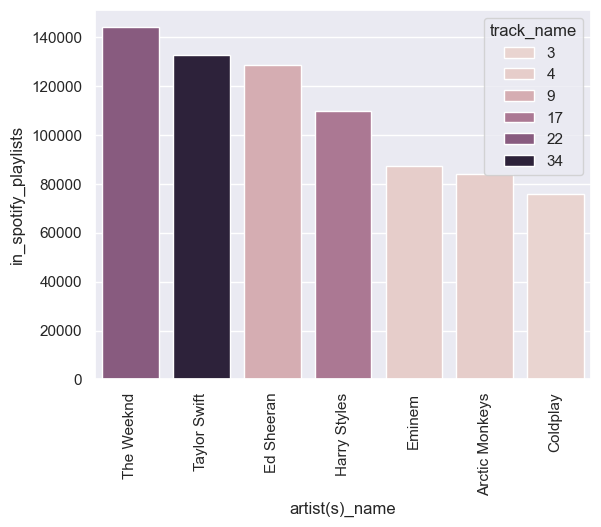

In [30]:
sns.barplot(artist_name_g,x='artist(s)_name',y='in_spotify_playlists',hue=('track_name'))
plt.xticks(rotation=90)
plt.show()

In [31]:
from sklearn.model_selection import train_test_split
df.head()
new_df=df[['in_spotify_playlists','streams']]

df['streams']=df['streams'].str.replace(r'[A-z]+','0',regex=True)


In [32]:
df['streams']=df['streams'].astype('float')

In [33]:
df.groupby('track_name')['streams'].sum().sort_values(ascending=False).reset_index(name='count')

,track_name,count
0,Love Grows (Where My Rosemary Goes),110053075069070000128.00
1,Blinding Lights,3703895074.00
2,Shape of You,3562543890.00
3,Someone You Loved,2887241814.00
4,Dance Monkey,2864791672.00
...,...,...
938,Overdrive,14780425.00
939,"Gol Bolinha, Gol Quadrado 2",11956641.00
940,QUEMA,11599388.00
941,Jhoome Jo Pathaan,1365184.00


IQR

In [34]:
q1=df['streams'].quantile(0.25)
q3=df['streams'].quantile(0.75)
IQR =q3-q1
upper=q3+1.5 * IQR
lower=q1-1.5 * IQR
df=df[(df['streams']<=upper)& (df['streams']>=lower  )]
# df[(df['streams']<=upper)& (df['streams']>=lower  )]['streams']

In [41]:
q1

141720999.0

In [35]:
df['streams'].max()

1457139296.0

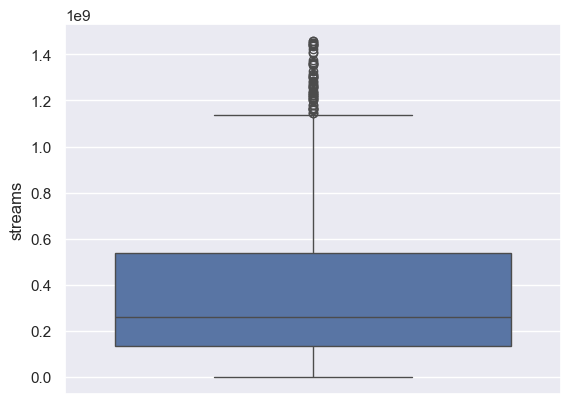

In [42]:
sns.boxplot(df['streams'])
# sns.histplot(df['streams'],bins=10)
plt.show()
# df['streames']
Q1=df['streams'].quantile(0.25)

In [37]:
df['streams'].describe()


count          878.00
mean     386487280.11
std      346950318.95
min           2762.00
25%      134490661.50
50%      259915815.00
75%      536670482.25
max     1457139296.00
Name: streams, dtype: float64

In [38]:
df.groupby(df.index.year)['track_name'].size()

datetime
1930      1
1942      1
1946      1
1950      1
1952      1
1957      2
1958      3
1959      2
1963      3
1968      1
1970      1
1971      1
1973      1
1979      1
1982      2
1984      3
1985      2
1986      2
1991      1
1992      1
1994      1
1995      2
1996      1
1997      1
1998      1
1999      4
2000      3
2002      2
2003      1
2004      4
2005      1
2007      1
2008      1
2010      5
2011      9
2012      4
2013      8
2014      9
2015      9
2016     12
2017     14
2018      7
2019     28
2020     29
2021    114
2022    401
2023    175
Name: track_name, dtype: int64

In [51]:
numeric_values=df.select_dtypes(include='number')
corrlation=numeric_values.corr()
corrlation['streams']

artist_count           -0.13
in_spotify_playlists    0.70
in_spotify_charts       0.19
streams                 1.00
in_apple_playlists      0.64
in_apple_charts         0.27
in_deezer_charts        0.24
bpm                     0.02
danceability_%         -0.08
valence_%              -0.07
energy_%               -0.02
acousticness_%         -0.04
instrumentalness_%     -0.01
liveness_%             -0.02
speechiness_%          -0.10
Name: streams, dtype: float64

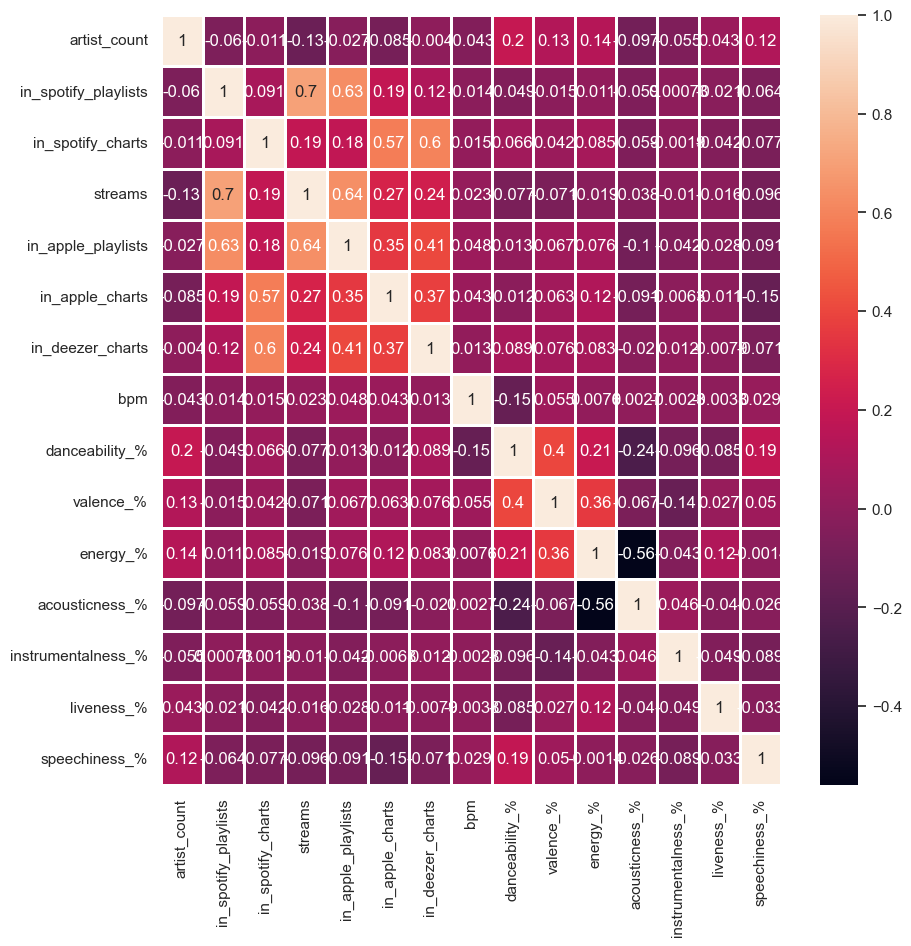

In [56]:
plt.figure(figsize=(10,10))
sns.heatmap(corrlation,annot=True,linewidths=0.8)
plt.show()

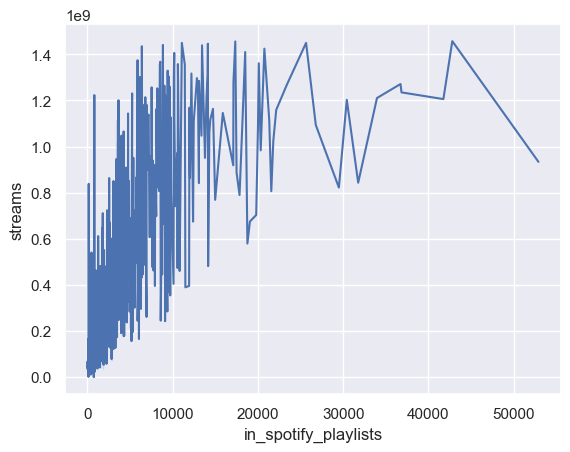

In [59]:
sns.lineplot(df,x='in_spotify_playlists',y='streams')
plt.show()

In [75]:
track_name=df.groupby('track_name')[['in_spotify_playlists','streams']].sum().sort_values(by='streams',ascending=False).reset_index().head(10)
track_name

,track_name,in_spotify_playlists,streams
0,Numb,23990,1656732038.00
1,Flowers,13012,1501682145.00
2,Somebody That I Used To Know,42798,1457139296.00
3,The Nights,17354,1456081449.00
4,Call Out My Name,11087,1449799467.00
5,All I Want for Christmas Is You,25653,1449779435.00
6,About Damn Time,11353,1447788946.00
7,Peaches (feat. Daniel Caesar & Giveon),14140,1445941661.00
8,Me Porto Bonito,8870,1440757818.00
9,Adore You,13454,1439191367.00


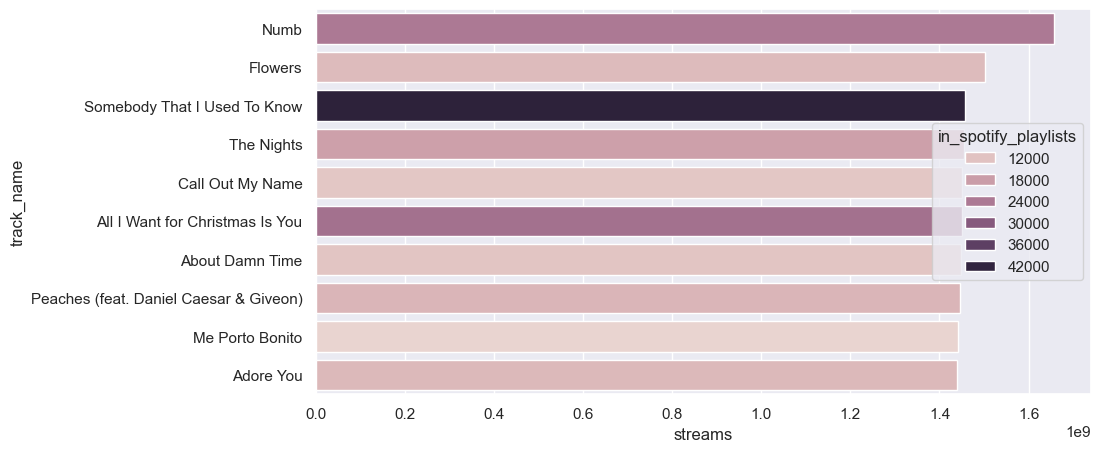

In [78]:
plt.figure(figsize=(10,5))
sns.barplot(track_name,x='streams',y='track_name',hue='in_spotify_playlists')
plt.show()
